In [1]:
#IMPORTAMOS LIBRERIAS
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
#DEFINICION DE MERCADOS
markets = {
    "SP500": "^GSPC",
    "NASDAQ": "^IXIC",
    "MEXICO": "^MXX",
    "BRAZIL": "^BVSP",
    "DAX": "^GDAXI",
    "CAC40": "^FCHI",
    "FTSE": "^FTSE",
    "NIKKEI": "^N225",
    "SHANGHAI": "000001.SS",
    "NIFTY": "^NSEI",
    "KOSPI": "^KS11",
    "ASX": "^AXJO"
}

In [3]:
#DESCARGA DE DATOS
data = pd.DataFrame()

for market, ticker in markets.items():

    prices = yf.download(
        ticker,
        start="2019-01-01",
        progress=False
    )["Close"]

    data[market] = prices

data = data.dropna()

print("Datos descargador:")
print(data.head())

Datos descargador:
                  SP500       NASDAQ        MEXICO   BRAZIL           DAX  \
Date                                                                        
2019-01-04  2531.939941  6738.859863  42455.128906  91841.0  10767.690430   
2019-01-07  2549.689941  6823.470215  42834.199219  91699.0  10747.809570   
2019-01-08  2574.409912  6897.000000  43542.871094  92032.0  10803.980469   
2019-01-09  2584.959961  6957.080078  43648.070312  93613.0  10893.320312   
2019-01-10  2596.639893  6986.069824  43668.949219  93806.0  10921.589844   

                  CAC40         FTSE        NIKKEI     SHANGHAI         NIFTY  \
Date                                                                            
2019-01-04  4737.120117  6837.399902  19561.960938  2514.867920  10727.349609   
2019-01-07  4719.169922  6810.899902  20038.970703  2533.089111  10771.799805   
2019-01-08  4773.270020  6861.600098  20204.039062  2526.461914  10802.150391   
2019-01-09  4813.580078  6906.600098

In [4]:
#CALCULO DE RETORNOS
returns = data.pct_change().dropna()
print("\nRetornos calculados:")
print(returns.head())


Retornos calculados:
               SP500    NASDAQ    MEXICO    BRAZIL       DAX     CAC40  \
Date                                                                     
2019-01-07  0.007010  0.012556  0.008929 -0.001546 -0.001846 -0.003789   
2019-01-08  0.009695  0.010776  0.016545  0.003631  0.005226  0.011464   
2019-01-09  0.004098  0.008711  0.002416  0.017179  0.008269  0.008445   
2019-01-10  0.004518  0.004167  0.000478  0.002062  0.002595 -0.001645   
2019-01-11 -0.000146 -0.002088 -0.002584 -0.001578 -0.003125 -0.005061   

                FTSE    NIKKEI  SHANGHAI     NIFTY     KOSPI       ASX  
Date                                                                    
2019-01-07 -0.003876  0.024385  0.007245  0.004144  0.013357  0.011354  
2019-01-08  0.007444  0.008237 -0.002616  0.002818 -0.005807  0.006897  
2019-01-09  0.006558  0.011038  0.007078  0.004906  0.019474  0.009769  
2019-01-10  0.005256 -0.012888 -0.003634 -0.003091 -0.000693  0.002942  
2019-01-11 -0.003558 

In [5]:
#APLICAMOS LA FUNCION DE MAX DRAWDOWN
def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

In [7]:
#APLICAMOS FEATURE ENGINEERING

features = pd.DataFrame(index=returns.columns)

# retorno anual
features["mean_return"] = returns.mean() * 252

# volatilidad anual
features["volatility"] = returns.std() * np.sqrt(252)

# asimetría
features["skewness"] = returns.skew()

# curtosis
features["kurtosis"] = returns.kurtosis()

# sharpe ratio
features["sharpe_ratio"] = (
    features["mean_return"] / features["volatility"]
)

# max drawdown
features["max_drawdown"] = returns.apply(max_drawdown)

# Value at Risk
features["VaR_95"] = returns.quantile(0.05)

# momentum anual
momentum = data.pct_change(252)
features["momentum"] = momentum.mean()

print("\nDataset de características:")
print(features)


Dataset de características:
          mean_return  volatility  skewness   kurtosis  sharpe_ratio  \
SP500        0.203952    0.211949 -0.078518  11.179736      0.962267   
NASDAQ       0.255475    0.256789  0.114139   6.188611      0.994882   
MEXICO       0.103411    0.189405 -0.473559   3.813501      0.545979   
BRAZIL       0.157252    0.256620 -0.646408  15.900140      0.612782   
DAX          0.168870    0.216324 -0.473816  12.518294      0.780635   
CAC40        0.119811    0.212969 -0.825751  11.465090      0.562576   
FTSE         0.091795    0.178953 -1.015345  16.098798      0.512958   
NIKKEI       0.222225    0.238474 -0.341809   8.994724      0.931863   
SHANGHAI     0.109670    0.189798  0.039170   7.303743      0.577825   
NIFTY        0.171759    0.194853 -0.520923  11.404252      0.881481   
KOSPI        0.219104    0.242241 -1.066801  21.026891      0.904490   
ASX          0.099515    0.174590 -0.776898   8.944039      0.569992   

          max_drawdown    VaR_95  

In [8]:
#ESCALADO DE DATOS
scaler = StandardScaler()

X = scaler.fit_transform(features)


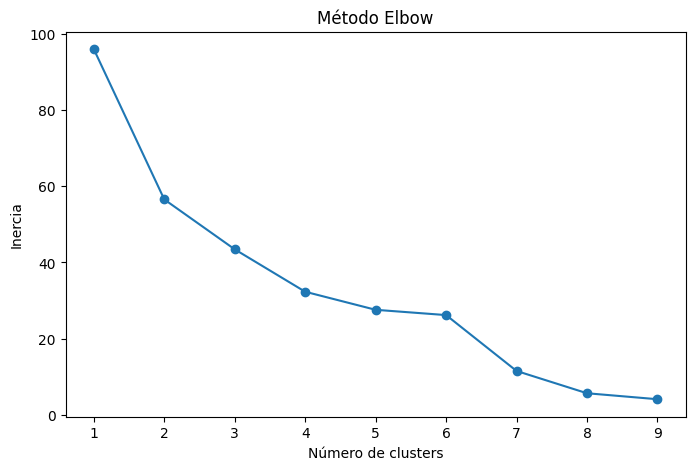

In [9]:
#MeTODO ELBOW
inertia = []

k_range = range(1,10)

for k in k_range:

    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia, marker="o")

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.title("Método Elbow")

plt.show()

In [10]:
#CLUSTERING KMEANS
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X)

features["cluster"] = clusters

print("\nClusters obtenidos:")
print(features)



Clusters obtenidos:
          mean_return  volatility  skewness   kurtosis  sharpe_ratio  \
SP500        0.203952    0.211949 -0.078518  11.179736      0.962267   
NASDAQ       0.255475    0.256789  0.114139   6.188611      0.994882   
MEXICO       0.103411    0.189405 -0.473559   3.813501      0.545979   
BRAZIL       0.157252    0.256620 -0.646408  15.900140      0.612782   
DAX          0.168870    0.216324 -0.473816  12.518294      0.780635   
CAC40        0.119811    0.212969 -0.825751  11.465090      0.562576   
FTSE         0.091795    0.178953 -1.015345  16.098798      0.512958   
NIKKEI       0.222225    0.238474 -0.341809   8.994724      0.931863   
SHANGHAI     0.109670    0.189798  0.039170   7.303743      0.577825   
NIFTY        0.171759    0.194853 -0.520923  11.404252      0.881481   
KOSPI        0.219104    0.242241 -1.066801  21.026891      0.904490   
ASX          0.099515    0.174590 -0.776898   8.944039      0.569992   

          max_drawdown    VaR_95  momentum

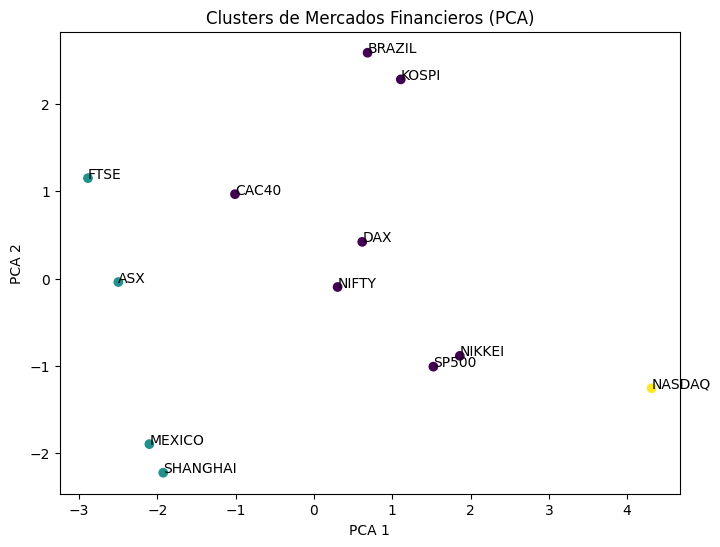

In [11]:
#VISUALIZACIÓN PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

for i, market in enumerate(features.index):

    plt.text(
        X_pca[i,0],
        X_pca[i,1],
        market
    )

plt.title("Clusters de Mercados Financieros (PCA)")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

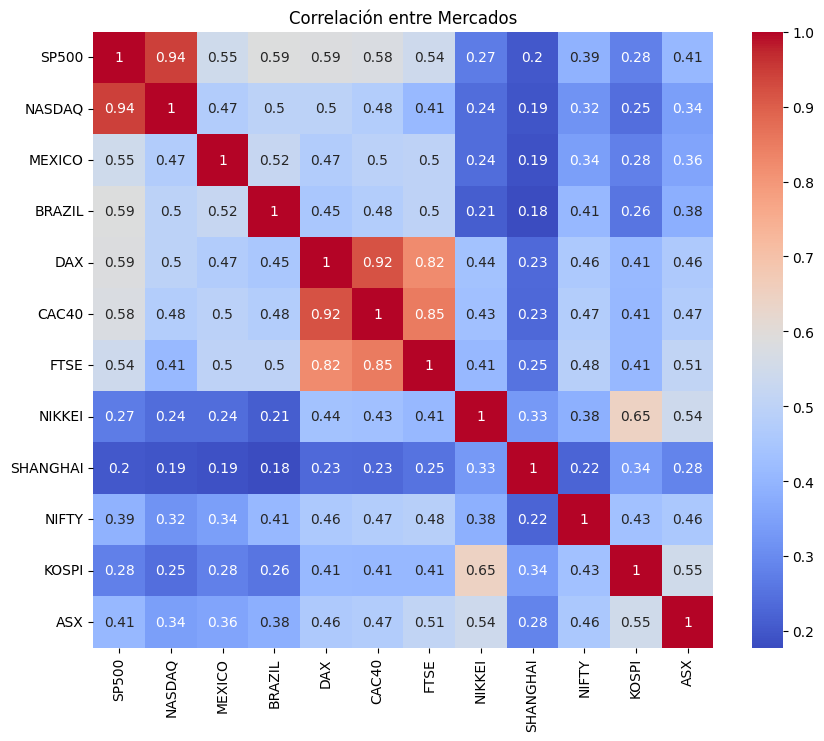

In [12]:
#MATRIZ DE CORRELACIÓN
plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación entre Mercados")

plt.show()

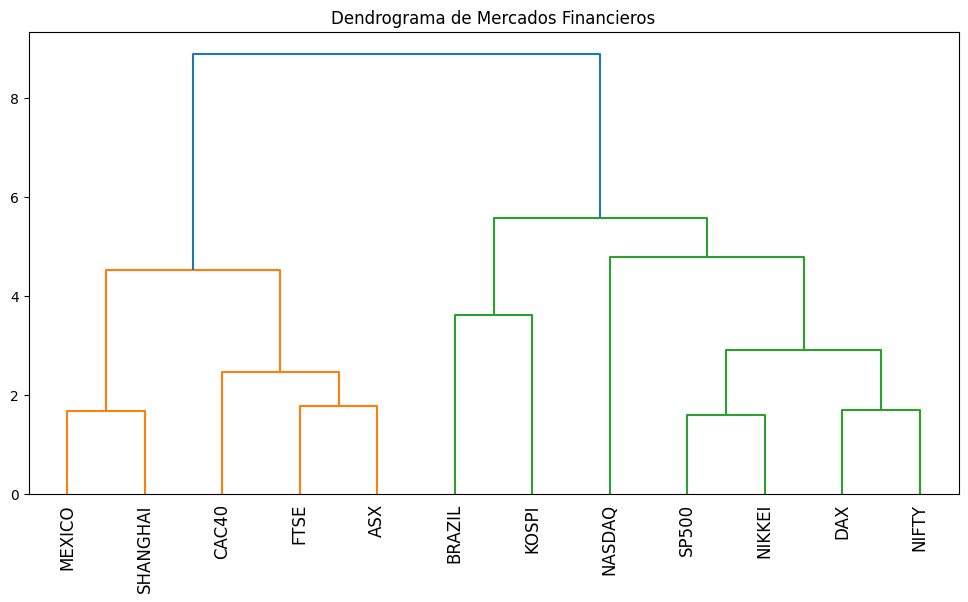

In [13]:
#CLUSTERING JERÁRQUICO
Z = linkage(X, method="ward")

plt.figure(figsize=(12,6))

dendrogram(
    Z,
    labels=features.index,
    leaf_rotation=90
)

plt.title("Dendrograma de Mercados Financieros")

plt.show()

C:\Users\salva\AppData\Local\Temp\ipykernel_7208\1837120660.py:7: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z_corr = linkage(distance, method="ward")


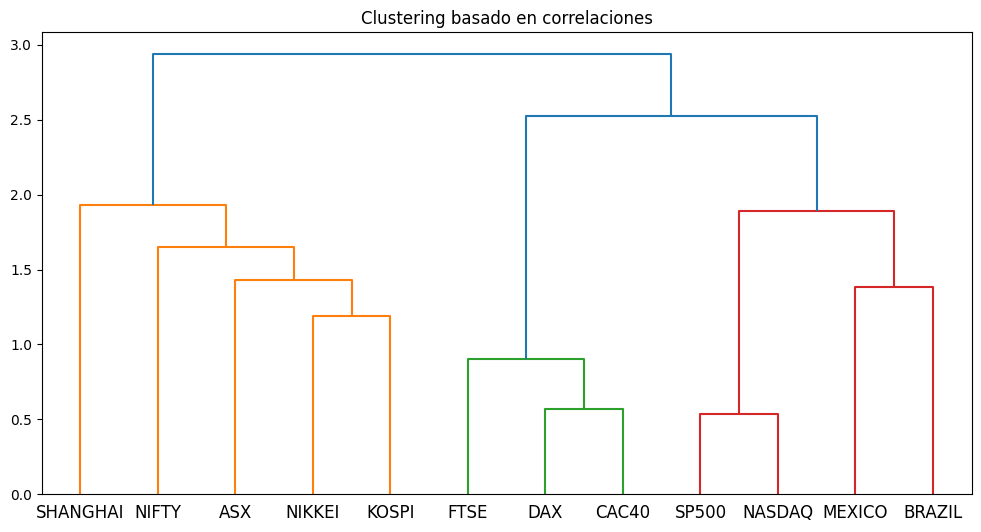

In [14]:
#CLUSTERING BASADO EN CORRELACIONES

corr = returns.corr()

distance = np.sqrt(2 * (1 - corr))

Z_corr = linkage(distance, method="ward")

plt.figure(figsize=(12,6))

dendrogram(
    Z_corr,
    labels=returns.columns
)

plt.title("Clustering basado en correlaciones")

plt.show()